# Treatment of Experimental Data Python Pre Lab Assignment (5 pts)

**Instructions:**  You are allowed to use any Jupyter Notebooks and/or Gemini to help you do this assignment; however, keep in mind that ***we will be disabling Gemini during lab and you will not have Gemini on any quizzes or exams (but you will have your lab notebook as these quizzes/exams are open notebook).*** Therefore, you should take the time to try to understand the general syntax while doing these assignments by taking notes in your lab notebooks as you've done previously. All concept check interactive quizzes are ungraded and have unlimited attempts.

:::{admonition} Overview
This pre-lab assignment is a refresher for the Python tutorials we did the first week of class.

**Questions:**
- How do we import data into Colab?
- How do we do a linear best fit regression?
- What type of plot is most appropriate for a set of data?

**Objectives:**
- Visualize data using Matplotlib.
- Create multiple types of plots using the same data.
:::

In [ ]:
# Import packages needed for this assignment
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
from scipy.stats import *

#Quizzes
from IPython.display import display, HTML

%pip install "jupyterquiz"
from jupyterquiz import display_quiz

import sys
sys.path.append('..')  # Add parent directory to path
import quiz_utils      # Now you can import it directly

# 1. Create a scatter plot and best fit line


:::{warning} ✏️ Exercise (2 pts)
:icon: false
In your scatter plot, include the following:

- The x and y axes labels and a legend.
- **Do not** include a title.
- Units of your choice relating to chemistry for the axes labels and legend.
:::

In [4]:
x=[0.4442, 0.9843, 1.3817, 1.847, 2.4451, 2.9484, 3.3576, 3.7833, 4.4037, 4.9502, 5.2665]
y=[5.3428, 8.2208, 11.1149, 14.1221, 17.3608, 20.1164, 23.4409, 26.2638, 29.1096, 32.0286, 35.2061]

### Concept Check

In [5]:
quiz_utils.json_to_quiz('../rotation1.json',"pre-lab-quiz")

<IPython.core.display.Javascript object>

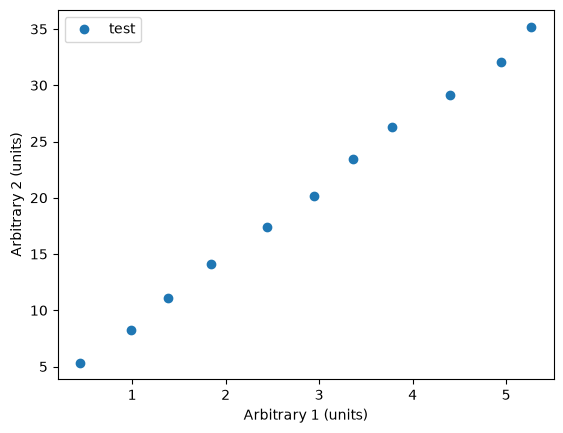

In [6]:
# Insert your code here for the scatter plot
plt.plot(x,y,'o',label='test')
plt.xlabel('Arbitrary 1 (units)')
plt.ylabel('Arbitrary 2 (units)')
plt.legend()
plt.show()

### Practice exporting your scatter plot

Copy the code block into the cell below and create a scatter plot that can be exported as a high-res image.

```python
fig = plt.figure(figsize=(5,5))
#----------------------------------------
#Your code for the scatter plot goes here
#----------------------------------------
fig.savefig('file.png',dpi=300,bbox_inches='tight')
```

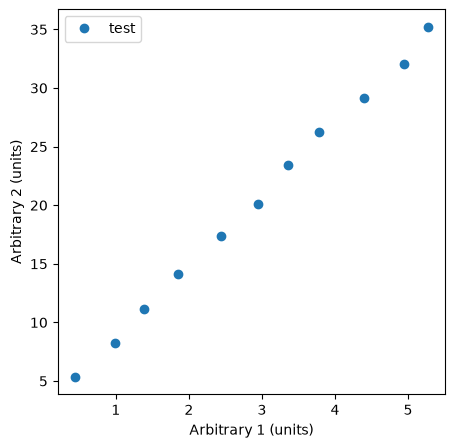

In [7]:
# Export your scatter plot into a png file
fig = plt.figure(figsize=(5,5))
plt.plot(x,y,'o',label='test')
plt.xlabel('Arbitrary 1 (units)')
plt.ylabel('Arbitrary 2 (units)')
plt.legend()
plt.show()
fig.savefig('file.png',dpi=300,bbox_inches='tight')

In [8]:
# Calculate the best fit line for this data
best_fit = sp.stats.linregress(x,y)

# Create m, b, and r2 variables that are equal to the slope, intercept, and r^2 value.
m=best_fit.slope
b=best_fit.intercept
r2=best_fit.rvalue**2

In [9]:
# Print the values for m, b, and r2
print('Slope: ',m)
print('Intercept: ',b)
print('r^2: ',r2)

Slope:  6.100452216475289
Intercept:  2.5690194626807354
r^2:  0.9980969634514766


# 2. Create various plots using pressure data

:::{warning} ✏️ Exercise (3 pts)
:icon: false
Import the pressure data in **Sample-Data/LAB1_PRELAB.xlsx** to calculate $\Delta_{95\%}p$. You can use Excel to calculate the confidence interval.

You will need to show the average pressure and the 95% confidence intervals for each of the following plots:

- Box plot.
- Violin plot.
- Histogram.

Use `plt.vlines` and `plt.hlines` to plot the 95% confidence intervals as red dashed lines.
:::

In [10]:
# Import the data from Sample-Data/LAB1_PRELAB.xlsx using pd.read_excel()
data = pd.read_excel('Sample-Data/LAB1_PRELAB.xlsx')
data

,pressure (kPa)
0,99.113
1,99.076
2,99.113
3,99.076
4,99.076
...,...
96,99.076
97,99.076
98,99.038
99,99.076


In [11]:
#Calculated via Python (I allowed students to use Excel)
ts2=np.abs(t.ppf(0.025,50))
avg=data.mean()
stdev=data.std(ddof=1)

# Variables defining upper and lower limits
# Students can use Excel to calculate these values and then place their answers here
upper=avg+ts2*stdev
lower=avg-ts2*stdev

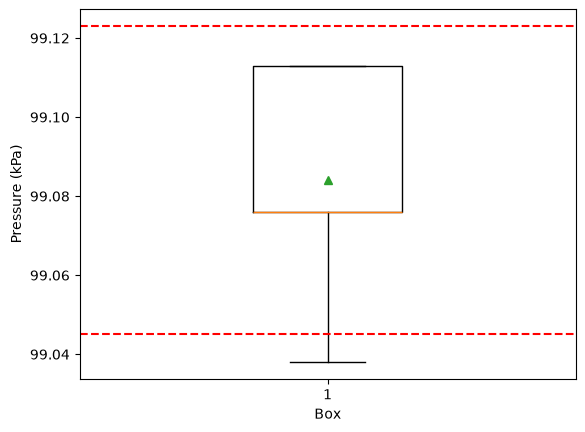

In [12]:
# Create a box plot of the data you just imported
# showmeans=True is an optional keyword students can include
plt.boxplot(data,showmeans=True)
plt.hlines(upper,0.75,1.25,color='r',linestyles='dashed')
plt.hlines(lower,0.75,1.25,color='r',linestyles='dashed')
plt.ylabel('Pressure (kPa)')
plt.xlabel('Box')
plt.xlim(0.75,1.25) # Optional for display
plt.show()

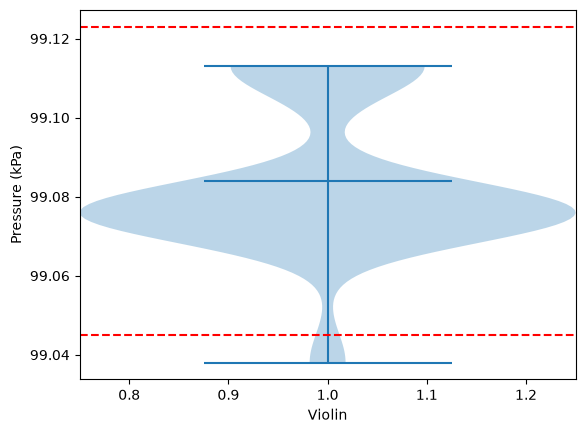

In [13]:
# Create a violin plot of the data you just imported
# showmeans=True is an optional keywords students can include
plt.violinplot(data,showmeans=True)
plt.ylabel('Pressure (kPa)')
plt.xlabel('Violin')
plt.hlines(upper,0.75,1.25,color='r',linestyles='dashed')
plt.hlines(lower,0.75,1.25,color='r',linestyles='dashed')
plt.xlim(0.75,1.25) #Optional for display
plt.show()

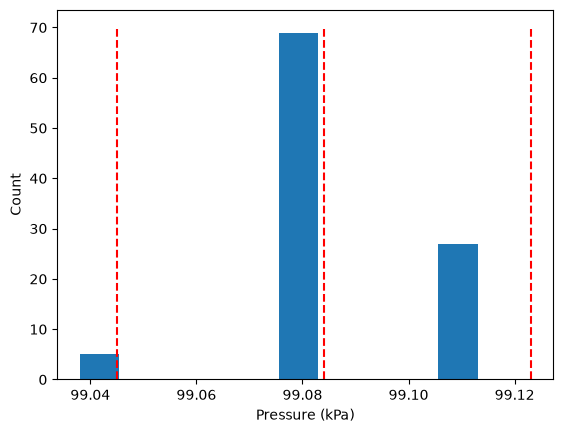

In [14]:
#Create a histogram of the data you just imported
plt.hist(data)
plt.xlabel('Pressure (kPa)')
plt.ylabel('Count')
plt.vlines(avg,0,70,color='r',linestyles='dashed')
plt.vlines(upper,0,70,color='r',linestyles='dashed')
plt.vlines(lower,0,70,color='r',linestyles='dashed')
plt.show()

# Questions

:::{danger} ❓ Question 1
:icon: false
Compare and contrast the three plots you generated. Which plot tells the most complete story of the data? Why?
:::{warning} 📝 Student Response
:icon: false
To record your response, double click the cell and type your answer after the `>` below!
> The box plot provides a concise summary of the pressure data by displaying the median, quartiles (Q1 and Q3), and any potential outliers. This makes it particularly useful for quickly assessing the central tendency and spread of the data. However, it does not convey any information about the shape of the distribution, such as whether the data is skewed or multimodal, which limits its ability to fully represent the underlying pattern of the dataset.

> The violin plot combines the features of both the box plot and the histogram. It includes the median and quartiles within a central box, while also showing a kernel density estimate that illustrates the full shape of the distribution. This dual representation allows for a richer understanding of how the data is concentrated and spread across its range.

> The histogram visualizes how frequently values occur within defined intervals, making it helpful for identifying modes or general distribution shapes. It can reveal whether the data is skewed, symmetric, or has multiple peaks. However, its interpretability is sensitive to the choice of bin width, and it does not provide explicit information about summary statistics like the median or quartiles.

> In this case, the violin plot provides the most complete picture of the pressure data. It captures the consistent clustering of values around 99.076 and 99.113, which is only hinted at in the histogram and obscured in the box plot. For datasets with subtle variation or repeated values, as seen here, the violin plot more clearly reveals both summary statistics and distributional patterns.
::::::

:::{admonition} Key Points
- Import data with `pd.read_csv()` or `pd.read_excel()`.
- Create numerous types of plots with `matplotlib`.
- Choose the most appropriate type of plot for a specific data type.
:::